<a href="https://colab.research.google.com/github/OvidioAscencio/TecnicasIndustriales/blob/main/Tecnicas_de_produccion_industrial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET CARGADO CORRECTAMENTE
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1

DIMENSIONES DEL DATASET
(102, 7)

NOMBRES DE COLUMNAS
Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')

INFORMACION GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   w

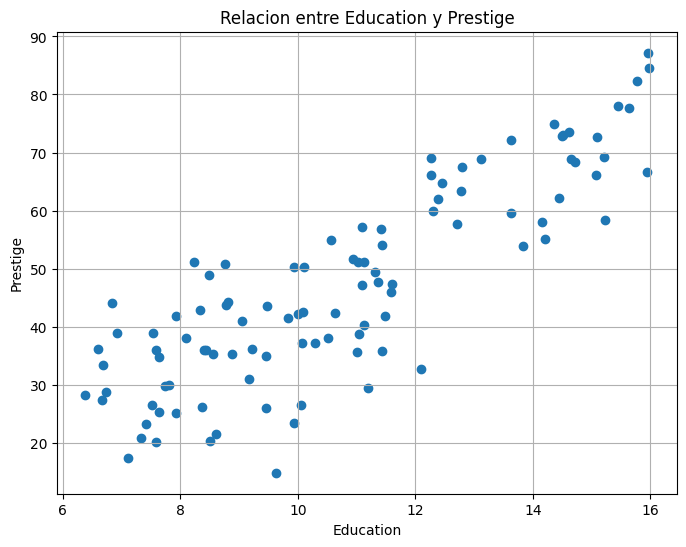

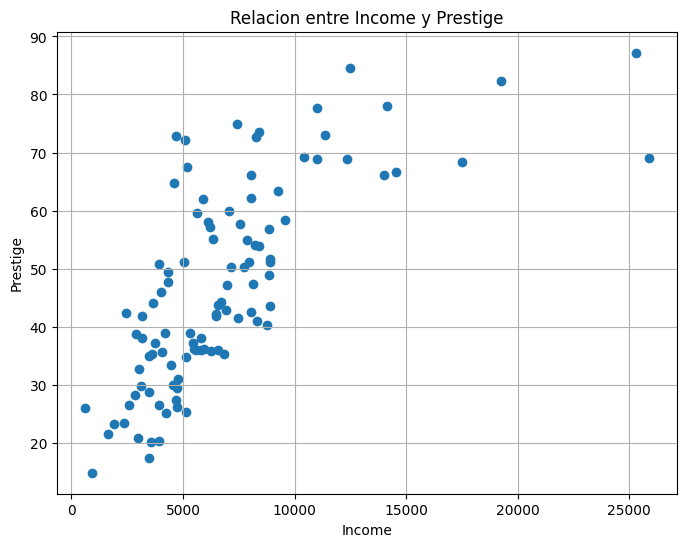

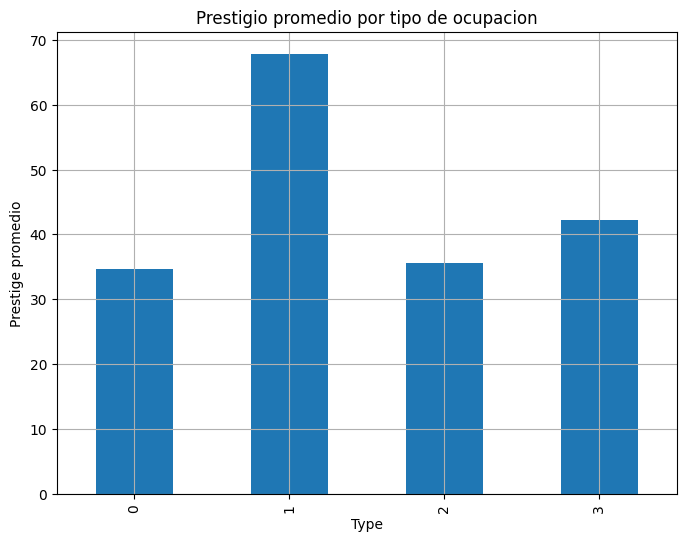


DATOS ESCALADOS CORRECTAMENTE

CENTROIDES MODELO K=4
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00

CENTROIDES MODELO K=5
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00

CANTIDAD DE REGISTROS POR CLUSTER K=4
Cluster_4
1    47
2    23
0    20
3    12
Name: count, dtype: int64

CANTIDAD DE REGISTROS POR CLUSTER K=5
Cluster_5
1    32
3    

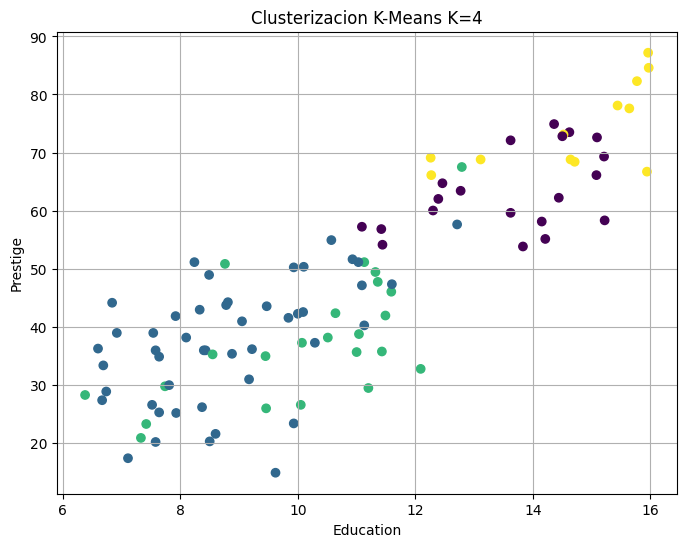

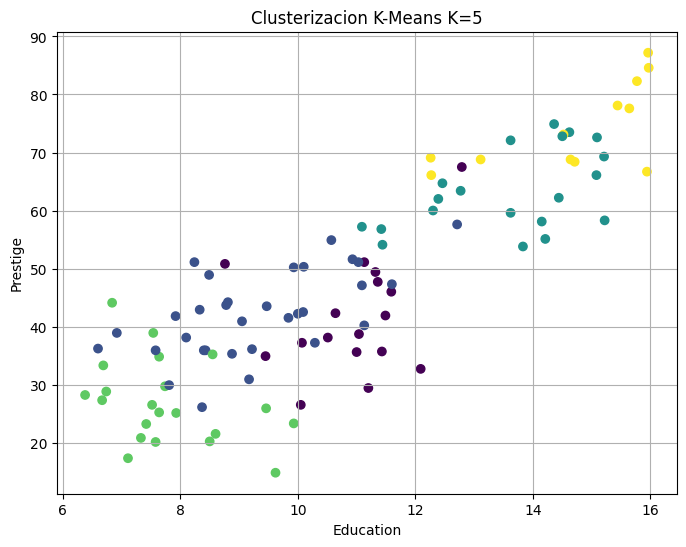


PRESTIGIO PROMEDIO POR CLUSTER K=4
Cluster_4
0    63.33
1    37.26
2    37.76
3    74.23
Name: prestige, dtype: float64

PRESTIGIO PROMEDIO POR CLUSTER K=5
Cluster_5
0    41.50
1    42.18
2    63.33
3    26.87
4    74.23
Name: prestige, dtype: float64


In [10]:
# ============================================================
# CASO PRACTICO APLICADO
# TECNICAS DE PRODUCCION INDUSTRIAL DE SOFTWARE
#
# Alumno:
# Nidelson Ovidio Ascencio Huezo
# ============================================================



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



url = "https://raw.githubusercontent.com/OvidioAscencio/TecnicasIndustriales/refs/heads/main/Dataset/Prestige_modificado.csv"

df = pd.read_csv(url, sep=';')

print("================================================")
print("DATASET CARGADO CORRECTAMENTE")
print("================================================")

print(df.head())



print("\n================================================")
print("DIMENSIONES DEL DATASET")
print("================================================")

print(df.shape)

print("\n================================================")
print("NOMBRES DE COLUMNAS")
print("================================================")

print(df.columns)

print("\n================================================")
print("INFORMACION GENERAL")
print("================================================")

print(df.info())

print("\n================================================")
print("VALORES NULOS")
print("================================================")

print(df.isnull().sum())

print("\n================================================")
print("REGISTROS DUPLICADOS")
print("================================================")

print(df.duplicated().sum())

print("\n================================================")
print("ESTADISTICA DESCRIPTIVA")
print("================================================")

print(df.describe())

print("\n================================================")
print("TIPOS DE DATOS")
print("================================================")

print(df.dtypes)



variables_numericas = [
    "education",
    "income",
    "women",
    "prestige",
    "census",
    "type_num"
]

print("\n================================================")
print("REVISION DE VALORES ATIPICOS")
print("================================================")

for columna in variables_numericas:

    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("\n----------------------------------------")
    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviacion estandar:", round(desviacion, 2))
    print("Limite inferior:", round(limite_inferior, 2))
    print("Limite superior:", round(limite_superior, 2))
    print("Cantidad de valores atipicos:", len(atipicos))


print("\n================================================")
print("MATRIZ DE CORRELACION")
print("================================================")

variables_correlacion = df.select_dtypes(
    include=['int64', 'float64']
)

matriz_correlacion = variables_correlacion.corr()

print(matriz_correlacion.round(3))

print("\n================================================")
print("CORRELACIONES CON PRESTIGE")
print("================================================")

correlaciones_prestige = (
    matriz_correlacion["prestige"]
    .sort_values(ascending=False)
)

print(correlaciones_prestige.round(3))



plt.figure(figsize=(8,6))

plt.scatter(
    df["education"],
    df["prestige"]
)

plt.xlabel("Education")
plt.ylabel("Prestige")
plt.title("Relacion entre Education y Prestige")

plt.grid(True)

plt.show()


plt.figure(figsize=(8,6))

plt.scatter(
    df["income"],
    df["prestige"]
)

plt.xlabel("Income")
plt.ylabel("Prestige")
plt.title("Relacion entre Income y Prestige")

plt.grid(True)

plt.show()



prestigio_por_tipo = (
    df.groupby("type_num")["prestige"]
    .mean()
)

plt.figure(figsize=(8,6))

prestigio_por_tipo.plot(kind="bar")

plt.xlabel("Type")
plt.ylabel("Prestige promedio")
plt.title("Prestigio promedio por tipo de ocupacion")

plt.grid(True)

plt.show()



columnas_cluster = [
    "education",
    "income",
    "women",
    "prestige",
    "type_num"
]

X = df[columnas_cluster].copy()



escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)

print("\n================================================")
print("DATOS ESCALADOS CORRECTAMENTE")
print("================================================")



modelo_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster_4"] = modelo_k4.fit_predict(X_escalado)

print("\n================================================")
print("CENTROIDES MODELO K=4")
print("================================================")

centroides_k4 = (
    df.groupby("Cluster_4")[columnas_cluster]
    .mean()
    .round(2)
)

print(centroides_k4)



modelo_k5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster_5"] = modelo_k5.fit_predict(X_escalado)

print("\n================================================")
print("CENTROIDES MODELO K=5")
print("================================================")

centroides_k5 = (
    df.groupby("Cluster_5")[columnas_cluster]
    .mean()
    .round(2)
)

print(centroides_k5)



print("\n================================================")
print("CANTIDAD DE REGISTROS POR CLUSTER K=4")
print("================================================")

print(df["Cluster_4"].value_counts())

print("\n================================================")
print("CANTIDAD DE REGISTROS POR CLUSTER K=5")
print("================================================")

print(df["Cluster_5"].value_counts())



plt.figure(figsize=(8,6))

plt.scatter(
    df["education"],
    df["prestige"],
    c=df["Cluster_4"]
)

plt.xlabel("Education")
plt.ylabel("Prestige")
plt.title("Clusterizacion K-Means K=4")

plt.grid(True)

plt.show()



plt.figure(figsize=(8,6))

plt.scatter(
    df["education"],
    df["prestige"],
    c=df["Cluster_5"]
)

plt.xlabel("Education")
plt.ylabel("Prestige")
plt.title("Clusterizacion K-Means K=5")

plt.grid(True)

plt.show()



print("\n================================================")
print("PRESTIGIO PROMEDIO POR CLUSTER K=4")
print("================================================")

print(
    df.groupby("Cluster_4")["prestige"]
    .mean()
    .round(2)
)

print("\n================================================")
print("PRESTIGIO PROMEDIO POR CLUSTER K=5")
print("================================================")

print(
    df.groupby("Cluster_5")["prestige"]
    .mean()
    .round(2)
)



df.to_csv(
    "Prestige_modificado_resultados.csv",
    index=False
)


print("================================================")






